# Task 3

## Dataset
A small English --> French subset of the Tatoeba dataset.

**setup**

In [9]:
# load imports, datasets, and BLEU

!pip install -q datasets sacrebleu

import math
import random
import re
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sacrebleu import corpus_bleu

SEED = 42 # fix standard random seed

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Using device: cuda


## Part 1: Scaled Dot-Product Attention

implements scaled dot-product attention completely from scratch using only:
- NumPy
- pandas
- No deep learning libraries

**scaled dot-product attention**

In [10]:
def softmax_numpy(x, axis=-1):
    # subtract the maximum value before exponentiating for numerical stability
    # prevents very large values in x from causing overflow in exp(...)
    x = x - np.max(x, axis=axis, keepdims=True)

    # exponentiate and normalize so values along the chosen axis sum to 1
    # converts raw attention scores into a probability distribution
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def scaled_dot_product_attention_numpy(Q, K, V, mask=None):
    """
    Q: (n_q, d_k) --> query vectors
    K: (n_k, d_k) --> key vectors
    V: (n_k, d_v) --> value vectors
    """
    # d_k is the key/query dimension. Used to scale the dot products,
    # following the scaled dot-product attention formula from lecture/Transformer
    # without scaling, large dot products can make softmax too sharp and unstable
    d_k = Q.shape[-1]

    # compute raw attention scores by comparing each query to every key
    # higher scores mean a query is more relevant to that key
    scores = np.matmul(Q, K.T) / np.sqrt(d_k)

    # if mask as arg, block disallowed positions by assigning a very
    # large negative number so their softmax probability becomes close to 0
    # needed for things like padding masks and causal masking
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)
    # convert scores into attention weights that sum to 1 across keys
    attention_weights = softmax_numpy(scores, axis=-1)
    # form the final attended representation as a weighted sum of value vectors
    output = np.matmul(attention_weights, V)

    # return:
    # 1. output: final context vectors
    # 2. attention_weights: normalized importance assigned to each key
    # 3. scores: raw scaled compatibility scores before softmax
    return output, attention_weights, scores

**small example**

In [11]:
# after attention weights are computed from Q and K, those weights are used
# to take a weighted combination of these value vectors:
Q = np.array([
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 1.0]
])

K = np.array([
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 0.0],
    [1.0, 1.0, 0.0]
])

V = np.array([
    [1.0, 10.0],
    [2.0, 20.0],
    [3.0, 30.0]
])

# run scaled dot-product attention on the toy example
# function returns:
# 1. raw compatibility scores between queries and keys,
# 2. normalized attention weights after softmax,
# 3. the final weighted output vectors
output, attn_weights, scores = scaled_dot_product_attention_numpy(Q, K, V)

# print intermediate and final results so we can verify the full attention pipeline:
# scores -> weights -> weighted sum of values
print("Scores:\n", scores)
print("\nAttention Weights:\n", attn_weights)
print("\nOutput:\n", output)

Scores:
 [[1.15470054 0.         0.57735027]
 [0.57735027 0.57735027 0.57735027]]

Attention Weights:
 [[0.53289684 0.16794345 0.29915971]
 [0.33333333 0.33333333 0.33333333]]

Output:
 [[ 1.76626287 17.66262875]
 [ 2.         20.        ]]


**put results in a pandas table**

In [12]:
# convert raw attention scores into a labeled DataFrame for readability
# rows represent queries (q1, q2) and columns represent keys (k1–k3),
# making it easier to interpret how strongly each query attends to each key
scores_df = pd.DataFrame(scores, index=["q1", "q2"], columns=["k1", "k2", "k3"])

# convert normalized attention weights (after softmax) into a DataFrame
# these weights represent the probability distribution over keys for each query,
# showing how attention is allocated (rows sum to 1 due to softmax)
weights_df = pd.DataFrame(attn_weights, index=["q1", "q2"], columns=["k1", "k2", "k3"])

# convert the final attention output into a DataFrame.
# each row corresponds to a query and contains the weighted sum of value vectors,
# which is the final output of the scaled dot-product attention mechanism.
output_df = pd.DataFrame(output, index=["q1", "q2"], columns=["v1", "v2"])

# display raw scaled dot-product scores before softmax
# these indicate similarity between queries and keys (higher = more relevant),
# but are not yet normalized or directly interpretable as probabilities
print("Scaled Dot-Product Scores")
display(scores_df)

# display attention weights after applying softmax
# this step converts scores into a normalized distribution,
# allowing the model to focus proportionally on the most relevant keys
print("Attention Weights After Softmax")
display(weights_df)

# display the final attention outputs
# these are computed as weighted sums of value vectors using the attention weights,
# representing the aggregated information each query extracts from the input
print("Final Weighted Output")
display(output_df)

Scaled Dot-Product Scores


,k1,k2,k3
q1,1.154701,0.00000,0.57735
q2,0.577350,0.57735,0.57735


Attention Weights After Softmax


,k1,k2,k3
q1,0.532897,0.167943,0.299160
q2,0.333333,0.333333,0.333333


Final Weighted Output


,v1,v2
q1,1.766263,17.662629
q2,2.000000,20.000000


**summary**
<br>
The scaled dot-product attention behaves as expected by producing meaningful similarity scores that reflect how strongly each query aligns with the keys. For q1, the scores are uneven, leading to a non-uniform softmax distribution where most attention is placed on k1, moderate attention on k3, and minimal attention on k2, resulting in a weighted output that emphasizes certain value vectors more than others. In contrast, q2 produces identical scores across all keys, yielding a uniform attention distribution and an output that is simply the average of all value vectors. This demonstrates that attention dynamically adapts based on query-key similarity: more distinctive queries produce selective weighting, while less distinctive ones distribute attention evenly. Overall, the results validate that the implementation correctly captures both selective and uniform attention behaviors depending on the input structure.

## parts 2-4

**load Tatoeba subset**

In [13]:
# was having trouble loading so had to search for a way to load via direct URL and found this:
!wget https://www.manythings.org/anki/fra-eng.zip
!unzip fra-eng.zip

--2026-04-01 20:16:25--  https://www.manythings.org/anki/fra-eng.zip
Resolving www.manythings.org (www.manythings.org)... 173.254.30.110
Connecting to www.manythings.org (www.manythings.org)|173.254.30.110|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8242175 (7.9M) [application/zip]
Saving to: ‘fra-eng.zip.1’

fra-eng.zip.1       100%[===================>]   7.86M  4.99MB/s    in 1.6s    

2026-04-01 20:16:27 (4.99 MB/s) - ‘fra-eng.zip.1’ saved [8242175/8242175]

Archive:  fra-eng.zip
replace _about.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: _about.txt              
replace fra.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: [y]
error:  invalid response [[y]]
replace fra.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fra.txt                 


In [14]:
import pandas as pd

df = pd.read_csv(
    "fra.txt",
    sep="\t", # tab separated so indicate where one column ends and next begins
    header=None,
    usecols=[0, 1], # only keep these bc these column hold source and target sentences
    names=["en", "fr"] # English and French
)

print(df.head())
print("Total pairs:", len(df))

    en          fr
0  Go.        Va !
1  Go.     Marche.
2  Go.  En route !
3  Go.     Bouge !
4  Hi.     Salut !
Total pairs: 240521


**extract sentence pairs**

In [15]:
# convert English and French columns into aligned sentence pairs for translation
# astype(str) ensures every entry is treated as text before training/preprocessing
pairs = list(zip(df["en"].astype(str), df["fr"].astype(str)))

# make sure data loaded correclty and pairs are aligned
print("Number of pairs:", len(pairs))
print("Example pair:")
print("EN:", pairs[0][0])
print("FR:", pairs[0][1])

Number of pairs: 240521
Example pair:
EN: Go.
FR: Va !


**train/val/test split**

In [16]:
# randomly shuffle the sentence pairs to remove any ordering bias
random.shuffle(pairs)

# split dataset into train/validation/test sets
train_pairs = pairs[:10000] # 10k samples to train model
val_pairs   = pairs[10000:11000] # 1k samples for val
test_pairs  = pairs[11000:12000] # 1k samples held out for final evaluation

# verify split is correct
print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

Train: 10000
Val: 1000
Test: 1000


**tokenization helpers**

In [17]:
def tokenize(text):
    text = text.lower().strip() # convert text to lower and remove leading/trailing whitespace for consistency
    text = re.sub(r"([?.!,¿'])", r" \1 ", text) # make punctuation separate tokens
    text = re.sub(r'[" "]+', " ", text) # replace multiple spaces with a single space
    return text.split() # split text into a list of tokens, produces final tokenized sequence to be used by model

**build vocabularies**

In [18]:
# define special tokens used in sequence modeling
# <pad>: used to pad sequences to equal length within a batch
# <unk>: represents unknown or rare words not in the vocabulary
# <bos>: marks the beginning of a sentence (used in decoding)
# <eos>: marks the end of a sentence (used for stopping generation)
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"

# keep all special tokens grouped for easy initialization of vocab
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

def build_vocab(sentences, min_freq=1, max_size=8000):
    # count frequency of each token across all sentences
    # this allows us to build a vocabulary based on most common words
    counter = Counter()
    for sent in sentences:
        counter.update(tokenize(sent)) # tokenize splits sentence into words/tokens

    # start vocab with special tokens so they always have fixed indices
    vocab = SPECIAL_TOKENS.copy()
    # add most frequent words to vocab up to max_size
    # min_freq=1 ensures we keep all words unless limited by max_size
    for word, freq in counter.most_common():
        if freq >= min_freq and word not in vocab:
            vocab.append(word)
        # limit vocab size to control memory usage and model complexity
        # 8000 is a reasonable tradeoff for small datasets (reduces sparsity while keeping coverage)
        if len(vocab) >= max_size:
            break
    # create mappings:
    # stoi (string --> index) for converting tokens to numbers (model input)
    # itos (index --> string) for decoding predictions back to text
    stoi = {tok: i for i, tok in enumerate(vocab)}
    itos = {i: tok for tok, i in stoi.items()}
    return stoi, itos


# build separate vocabularies for source and target languages
# this is necessary because source and target may have different word distributions
src_stoi, src_itos = build_vocab([src for src, _ in train_pairs], max_size=8000)
tgt_stoi, tgt_itos = build_vocab([tgt for _, tgt in train_pairs], max_size=8000)

# store indices of special tokens for quick access during training/inference
# these are frequently used for padding, masking, and sequence control
SRC_PAD_IDX = src_stoi[PAD_TOKEN]
SRC_UNK_IDX = src_stoi[UNK_TOKEN]
SRC_BOS_IDX = src_stoi[BOS_TOKEN]
SRC_EOS_IDX = src_stoi[EOS_TOKEN]

TGT_PAD_IDX = tgt_stoi[PAD_TOKEN]
TGT_UNK_IDX = tgt_stoi[UNK_TOKEN]
TGT_BOS_IDX = tgt_stoi[BOS_TOKEN]
TGT_EOS_IDX = tgt_stoi[EOS_TOKEN]

# print vocab size to verify construction and make sure they're in max_size
print("Source vocab size:", len(src_stoi))
print("Target vocab size:", len(tgt_stoi))

Source vocab size: 4741
Target vocab size: 7147


**numericalization helpers**

In [19]:
# maximum sequence lengths for source and target sentences
# cap sequences at 20 tokens to keep training computationally efficient
# and ensure consistent tensor shapes for batching
# reasonable for a small dataset where most sentences are short
MAX_SRC_LEN = 20
MAX_TGT_LEN = 20

def numericalize(text, stoi, max_len):
    # convert raw text into a sequence of token IDs using vocab
    # tokenize input sentence into individual words/subwords
    tokens = tokenize(text)

    # match each token to its integer ID
    ids = [stoi.get(tok, stoi[UNK_TOKEN]) for tok in tokens]
    # add BOS (start) and EOS (end) tokens to mark sequence boundaries
    # truncate to max_len - 2 to reserve space for these special tokens
    ids = [stoi[BOS_TOKEN]] + ids[:max_len - 2] + [stoi[EOS_TOKEN]]
    return ids

def pad_sequence(seq, max_len, pad_idx):
    # ensure all sequences have same length for batching
    # truncate sequences longer than max_len
    seq = seq[:max_len]
    # pad shorter sequences with PAD tokens so all sequences are equal length, required for efficient matrix ops in training
    seq = seq + [pad_idx] * (max_len - len(seq))
    return seq

**dataset class**

In [20]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_stoi, tgt_stoi, max_src_len, max_tgt_len):
        """
        Custom dataset for machine translation

        pairs: list of (source_sentence, target_sentence)
        src_stoi / tgt_stoi: vocab dictionaries mapping tokens --> indices
        max_src_len / max_tgt_len: fixed sequence lengths for batching
        """
        self.data = []
        for src_text, tgt_text in pairs:
            # convert tokens to integer IDs using vocab mappings
            # this is required because models operate on numbers, not raw text
            src_ids = numericalize(src_text, src_stoi, max_src_len)
            tgt_ids = numericalize(tgt_text, tgt_stoi, max_tgt_len)

            # pad sequences to fixed length so all inputs in a batch have equal size
            # padding is necessary for efficient tensor batching in PyTorch
            src_ids = pad_sequence(src_ids, max_src_len, src_stoi[PAD_TOKEN])
            tgt_ids = pad_sequence(tgt_ids, max_tgt_len, tgt_stoi[PAD_TOKEN])

            # store as tensors
            self.data.append((
                torch.tensor(src_ids, dtype=torch.long),
                torch.tensor(tgt_ids, dtype=torch.long)
            ))

    def __len__(self):
        # return total number of sentence pairs, needed for dataloader
        return len(self.data)

    def __getitem__(self, idx):
        # retrieve a single (source, target pair by index)
        return self.data[idx]

**DataLoaders**

In [21]:
BATCH_SIZE = 64

train_dataset = TranslationDataset(train_pairs, src_stoi, tgt_stoi, MAX_SRC_LEN, MAX_TGT_LEN)
val_dataset   = TranslationDataset(val_pairs, src_stoi, tgt_stoi, MAX_SRC_LEN, MAX_TGT_LEN)
test_dataset  = TranslationDataset(test_pairs, src_stoi, tgt_stoi, MAX_SRC_LEN, MAX_TGT_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

DataLoaders ready.


## Part 2 — Seq2Seq with Scaled Dot-Product Attention

Model choice:
- Encoder-decoder seq2seq model
- BiGRU encoder
- GRU decoder

How attention is integrated:
- The encoder first produces hidden states with a BiGRU.
- Then scaled dot-product **self-attention** is applied over the encoder outputs.
- The decoder also uses scaled dot-product attention over encoder outputs to compute context at each decoding step.

This is a simple and valid way to integrate scaled dot-product attention into the encoder architecture while still using a conventional seq2seq framework.

**torch scaled dot-product attention function**

In [22]:
def scaled_dot_product_attention_torch(Q, K, V, mask=None):
    """
    Q: (..., q_len, d_k)
    K: (..., k_len, d_k)
    V: (..., k_len, d_v)
    """
    # get key/query dimensionality (used for scaling to stabilize gradients)
    d_k = Q.size(-1)

    # compute raw attention scores via dot product between Q and K^T
    # transpose swaps last two dims of K so shapes align: (..., q_len, k_len)
    # divide by sqrt(d_k) to prevent large values --> avoids softmax saturation
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # apply mask if provided (used in decoder to block future tokens or pad tokens)
    # positions where mask == 0 get large negative value so softmax -> 0 prob
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    # convert scores to probabilities across keys (last dim = k_len)
    # each query attends to all keys with normalized weights
    attn_weights = torch.softmax(scores, dim=-1)

    # compute weighted sum of values using attention weights
    # produces context vectors capturing relevant info per query
    output = torch.matmul(attn_weights, V)

    # return both output (context) and attention weights (useful for analysis/visualization)
    return output, attn_weights

**encoder with self-attention**

In [23]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hidden_dim, dec_hidden_dim):
        super().__init__()

        # embedding layer maps token indices -> dense vectors
        # padding_idx ensures pad tokens do not update during training
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=SRC_PAD_IDX)

        # bidirectional GRU encodes sequence in both forward + backward directions
        # doubles hidden size (2H) -> captures past + future context per token
        self.rnn = nn.GRU(
            emb_dim,
            enc_hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # linear projections to create Q, K, V from encoder outputs
        # needed to apply scaled dot-product attention within encoder
        self.q_proj = nn.Linear(enc_hidden_dim * 2, enc_hidden_dim * 2)
        self.k_proj = nn.Linear(enc_hidden_dim * 2, enc_hidden_dim * 2)
        self.v_proj = nn.Linear(enc_hidden_dim * 2, enc_hidden_dim * 2)

        # project concatenated bidirectional hidden state -> decoder hidden size
        # ensures encoder/decoder dimensional compatibility
        self.fc_hidden = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)

        # project attention-enhanced outputs to decoder dimension
        # aligns encoder outputs with decoder input expectations
        self.fc_outputs = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)

    def forward(self, src):
        # convert token indices -> embeddings (B, S, E)
        embedded = self.embedding(src)

        # pass through BiGRU -> contextual representations for each token
        # outputs: (B, S, 2H), hidden: (2, B, H)
        outputs, hidden = self.rnn(embedded)

        # compute Q, K, V from encoder outputs for self-attention
        # allows each token to attend to all others in sequence
        Q = self.q_proj(outputs)
        K = self.k_proj(outputs)
        V = self.v_proj(outputs)

        # apply scaled dot-product attention over encoder outputs
        # enhances representations by weighting important tokens
        attended_outputs, _ = scaled_dot_product_attention_torch(Q, K, V)

        # project attended outputs to decoder dimension (B, S, D)
        outputs = self.fc_outputs(attended_outputs)

        # concatenate final forward + backward hidden states (last layer)
        # hidden[-2] = forward, hidden[-1] = backward
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)   # (B, 2H)

        # transform to decoder hidden size and apply nonlinearity
        # unsqueeze to match decoder expected shape (1, B, D)
        hidden = torch.tanh(self.fc_hidden(hidden_cat)).unsqueeze(0)

        # return sequence outputs + initial decoder hidden state
        return outputs, hidden

**decoder with attention**

In [24]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()

        # embedding layer maps target token indices -> dense vectors
        # padding_idx prevents pad token embeddings from learning
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=TGT_PAD_IDX)

        # GRU takes current token embedding + context vector from attention
        # input size = emb_dim + hidden_dim since both are concatenated
        self.rnn = nn.GRU(emb_dim + hidden_dim, hidden_dim, batch_first=True)

        # final prediction layer uses decoder output, attention context, and embedding
        # combining all 3 gives model current token info + decoder state + source context
        self.fc_out = nn.Linear(hidden_dim * 2 + emb_dim, output_dim)

    def forward(self, input_token, hidden, encoder_outputs):
        # input_token starts as shape (B,), one token per sequence at current step
        # unsqueeze adds time dimension so embedding/RNN expect sequence input
        input_token = input_token.unsqueeze(1) # (B, 1)

        # embed current decoder input token
        embedded = self.embedding(input_token) # (B, 1, E)

        # decoder hidden state acts as attention query
        # transpose from (1, B, H) --> (B, 1, H) to match attention function
        query = hidden.transpose(0, 1) # (B, 1, H)

        # attend over all encoder outputs using current decoder state
        # encoder_outputs serve as both keys + values
        # context tells decoder which source words matter most right now
        context, attn_weights = scaled_dot_product_attention_torch(
            query, encoder_outputs, encoder_outputs
        )

        # concatenate current target embedding with source context
        # gives GRU both what it has generated so far + relevant source info
        rnn_input = torch.cat((embedded, context), dim=2) # (B, 1, E+H)

        # update decoder hidden state for this time step
        output, hidden = self.rnn(rnn_input, hidden) # output: (B,1,H)

        # combine decoder output, attention context, and token embedding
        # this richer representation is used to predict next target token
        pred_input = torch.cat(
            (output.squeeze(1), context.squeeze(1), embedded.squeeze(1)),
            dim=1
        )

        # project to vocabulary size -> logits for each possible next token
        prediction = self.fc_out(pred_input) # (B, vocab)

        # return token prediction, updated hidden state, and attention weights
        return prediction, hidden, attn_weights

**seq2seq wrapper**

In [25]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        # store encoder + decoder as 2 main parts of seq2seq architecture
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # get basic batch/sequence/vocab sizes needed for decoding loop
        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        tgt_vocab_size = self.decoder.embedding.num_embeddings

        # preallocate tensor to store decoder predictions at each target step
        # shape = (batch, target sequence length, target vocab size)
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size, device=src.device)

        # encode full source sequence once
        # encoder_outputs used for attention, hidden initializes decoder
        encoder_outputs, hidden = self.encoder(src)

        # start decoding with first target token, usually <bos>
        input_token = tgt[:, 0]  # <bos>

        # decode one token at time, starting after <bos>
        for t in range(1, tgt_len):
            # generate prediction for current step using previous token,
            # current hidden state, and encoder outputs
            output, hidden, _ = self.decoder(input_token, hidden, encoder_outputs)
            outputs[:, t, :] = output

            # greedy choice: select highest-logit token as model prediction
            top1 = output.argmax(1)

            # teacher forcing randomly decides whether next input comes from
            # ground-truth target or model's own prediction
            # 0.5 is common balanced choice: helps training stability while still
            # forcing model to learn to rely on own outputs sometimes
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if teacher_force else top1

        # return all decoder logits for loss computation across sequence
        return outputs

**build seq2seq model**

In [26]:
# set embedding sizes for encoder + decoder
# 64 chosen as smaller, efficient size (assignment uses reduced model complexity)
ENC_EMB_DIM = 64
DEC_EMB_DIM = 64

# encoder hidden size kept moderate (64) to limit computation while still capturing context
ENC_HIDDEN_DIM = 64

# decoder hidden size larger (128) since it combines bidirectional encoder states (2*64)
# allows richer representation during generation
DEC_HIDDEN_DIM = 128

# initialize encoder with vocab size and chosen dimensions
# input_dim = size of source vocabulary
encoder = Encoder(
    input_dim=len(src_stoi),
    emb_dim=ENC_EMB_DIM,
    enc_hidden_dim=ENC_HIDDEN_DIM,
    dec_hidden_dim=DEC_HIDDEN_DIM
)

# initialize decoder with target vocab size and matching hidden dim
decoder = Decoder(
    output_dim=len(tgt_stoi),
    emb_dim=DEC_EMB_DIM,
    hidden_dim=DEC_HIDDEN_DIM
)

# combine encoder + decoder into full seq2seq model
# move model to device (GPU if available for faster training)
seq2seq_model = Seq2Seq(encoder, decoder)

# cross entropy loss for token prediction
# ignore_index ensures padding tokens do not contribute to loss (important for seq tasks)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

# Adam optimizer chosen for adaptive learning rates and stable convergence
# lr=1e-3 is standard default that works well for many NLP tasks
optimizer = torch.optim.Adam(seq2seq_model.parameters(), lr=1e-3)

# print model architecture for verification/debugging
print(seq2seq_model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(4741, 64, padding_idx=0)
    (rnn): GRU(64, 64, batch_first=True, bidirectional=True)
    (q_proj): Linear(in_features=128, out_features=128, bias=True)
    (k_proj): Linear(in_features=128, out_features=128, bias=True)
    (v_proj): Linear(in_features=128, out_features=128, bias=True)
    (fc_hidden): Linear(in_features=128, out_features=128, bias=True)
    (fc_outputs): Linear(in_features=128, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(7147, 64, padding_idx=0)
    (rnn): GRU(192, 128, batch_first=True)
    (fc_out): Linear(in_features=320, out_features=7147, bias=True)
  )
)


**training and evaluation helpers for seq2seq**

In [27]:
def train_seq2seq(model, loader, optimizer, criterion):
    # set model to training mode (enables dropout, etc.)
    model.train()
    total_loss = 0

    for src, tgt in loader:
        # move batch to device (GPU if available)

        # clear previous gradients to avoid accumulation
        optimizer.zero_grad()

        # forward pass with teacher forcing (helps stabilize training early on)
        output = model(src, tgt, teacher_forcing_ratio=0.5)

        # reshape outputs for loss computation
        # ignore first token (<bos>) since no prediction is made for it
        output_dim = output.size(-1)
        output = output[:, 1:, :].reshape(-1, output_dim)
        tgt_y = tgt[:, 1:].reshape(-1)

        # compute cross entropy loss between predictions and true tokens
        loss = criterion(output, tgt_y)

        # backpropagate gradients
        loss.backward()

        # clip gradients to prevent exploding gradients (common in RNNs)
        # 1.0 is standard safe threshold
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # update model parameters
        optimizer.step()

        # accumulate batch loss
        total_loss += loss.item()

    # return average loss across all batches
    return total_loss / len(loader)


def evaluate_seq2seq_loss(model, loader, criterion):
    # set model to evaluation mode (disables dropout, etc.)
    model.eval()
    total_loss = 0

    # disable gradient computation for efficiency
    with torch.no_grad():
        for src, tgt in loader:

            # no teacher forcing during evaluation (model relies fully on own predictions)
            output = model(src, tgt, teacher_forcing_ratio=0.0)

            # reshape same as training for consistent loss computation
            output_dim = output.size(-1)
            output = output[:, 1:, :].reshape(-1, output_dim)
            tgt_y = tgt[:, 1:].reshape(-1)

            # compute loss
            loss = criterion(output, tgt_y)
            total_loss += loss.item()

    # return average validation loss
    return total_loss / len(loader)

**train seq2seq model**

In [28]:
# number of training epochs kept relatively small for faster experimentation
# 8 chosen as balance between learning meaningful patterns and runtime constraints
SEQ2SEQ_EPOCHS = 8

# store loss values over time for later analysis/plotting
seq2seq_train_losses = []
seq2seq_val_losses = []

# track total training time for comparison (important for assignment analysis)
start_time = time.time()

# main training loop
for epoch in range(1, SEQ2SEQ_EPOCHS + 1):
    # train for one full pass over training data
    train_loss = train_seq2seq(seq2seq_model, train_loader, optimizer, criterion)

    # evaluate on validation set to monitor generalization
    val_loss = evaluate_seq2seq_loss(seq2seq_model, val_loader, criterion)

    # store losses to analyze trends (e.g., convergence, overfitting)
    seq2seq_train_losses.append(train_loss)
    seq2seq_val_losses.append(val_loss)

    # print progress each epoch for visibility/debugging
    print(f"Epoch {epoch}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

# compute total training time
seq2seq_training_time = time.time() - start_time

# print runtime (used later to compare with transformer performance)
print(f"Seq2Seq training time: {seq2seq_training_time:.2f} seconds")

Epoch 1: train_loss=5.4992  val_loss=5.1708
Epoch 2: train_loss=4.4921  val_loss=4.8865
Epoch 3: train_loss=4.0291  val_loss=4.7103
Epoch 4: train_loss=3.6271  val_loss=4.6062
Epoch 5: train_loss=3.2521  val_loss=4.5186
Epoch 6: train_loss=2.8833  val_loss=4.5533
Epoch 7: train_loss=2.5849  val_loss=4.5676
Epoch 8: train_loss=2.3109  val_loss=4.5935
Seq2Seq training time: 50.28 seconds


**analysis**
<br>
Training loss decreases steadily, showing the model is learning effectively, while validation loss improves early but plateaus and slightly worsens after around epoch 5, indicating onset of overfitting. This suggests the model benefits from early stopping around epochs 4-5 for best generalization.

**plot seq2seq losses**

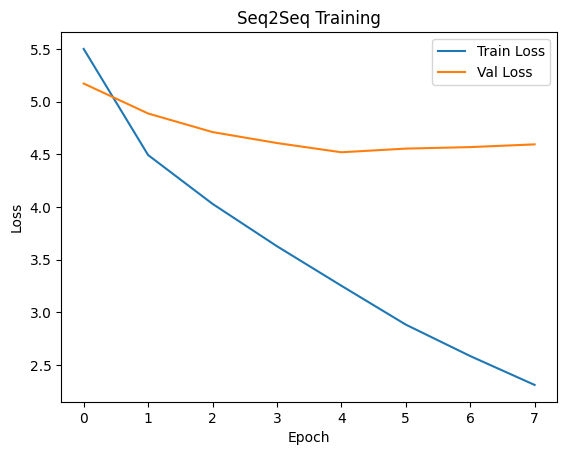

In [29]:
plt.plot(seq2seq_train_losses, label="Train Loss")
plt.plot(seq2seq_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Seq2Seq Training")
plt.legend()
plt.show()

Training loss decreases consistently, indicating strong learning, while validation loss improves initially but plateaus and slightly rises after about epoch 45, signaling overfitting. The widening gap between train and validation curves suggests the model is memorizing training data rather than improving generalization, making epoch 4-5 the optimal stopping point.

## Part 3: Machine Translation and BLEU

**greedy decoding helper**

In [30]:
def ids_to_sentence(ids, itos, eos_idx, pad_idx, bos_idx):
    # convert list of token ids -> readable sentence string
    tokens = []

    for idx in ids:
        idx = int(idx)

        # stop decoding once end-of-sequence token is reached
        if idx == eos_idx:
            break

        # skip padding and beginning-of-sequence tokens (not part of actual sentence)
        if idx in [pad_idx, bos_idx]:
            continue

        # map id -> token, fallback to UNK if missing
        tokens.append(itos.get(idx, UNK_TOKEN))

    # join tokens into space-separated sentence
    return " ".join(tokens)


def translate_seq2seq(model, src_tensor, max_len=20):
    # set model to eval mode for inference
    model.eval()

    # add batch dimension (model expects batch input)
    src_tensor = src_tensor.unsqueeze(0)

    with torch.no_grad():
        # encode source sentence once
        encoder_outputs, hidden = model.encoder(src_tensor)

        # start decoding with <bos> token
        input_token = torch.tensor([TGT_BOS_IDX])

        # store generated token ids
        generated_ids = []

        # generate tokens one step at a time (autoregressive decoding)
        # max_len prevents infinite loops if <eos> is never produced
        for _ in range(max_len):
            # get prediction for next token
            output, hidden, _ = model.decoder(input_token, hidden, encoder_outputs)

            # greedy decoding: choose highest probability token
            pred_token = output.argmax(1).item()

            # stop if end-of-sequence token generated
            if pred_token == TGT_EOS_IDX:
                break

            # store predicted token and feed it back into decoder
            generated_ids.append(pred_token)
            input_token = torch.tensor([pred_token], device=device)

    # return generated sequence of token ids
    return generated_ids

**compute BLEU for seq2seq on test set**

In [31]:
# lists to store predicted translations and ground-truth references
references = []
predictions = []

# loop through test dataset (no batching since evaluating sentence-by-sentence)
for src, tgt in test_dataset:
    # generate predicted token ids using trained seq2seq model
    pred_ids = translate_seq2seq(seq2seq_model, src)

    # convert predicted ids -> readable sentence
    pred_sent = ids_to_sentence(pred_ids, tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    # convert ground-truth target ids -> sentence (for BLEU comparison)
    tgt_sent = ids_to_sentence(tgt.tolist(), tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    # BLEU expects predictions as list of strings
    predictions.append(pred_sent)

    # BLEU expects references as list of list of strings (supports multiple refs per prediction)
    # here only one reference per sentence
    references.append([tgt_sent])

# compute corpus-level BLEU score across all predictions
# evaluates n-gram overlap between predicted and reference translations
seq2seq_bleu = corpus_bleu(predictions, references)

# print BLEU score (higher = better translation quality)
print("Seq2Seq BLEU Score:", seq2seq_bleu.score)

Seq2Seq BLEU Score: 42.72870063962342


**analysis**
<br>
A BLEU score of 42.7 indicates reasonably strong translation quality, with the model capturing many correct words and phrases, though there is still room for improvement in fluency and exact sequence alignment.

**show example translations**

In [32]:
# display a few qualitative translation examples for inspection
# helps understand model behavior beyond BLEU score
for i in range(5):
    # get source and target tensors from test set
    src_tensor, tgt_tensor = test_dataset[i]

    # convert source + reference target from ids --> readable text
    src_text = ids_to_sentence(src_tensor.tolist(), src_itos, SRC_EOS_IDX, SRC_PAD_IDX, SRC_BOS_IDX)
    tgt_text = ids_to_sentence(tgt_tensor.tolist(), tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    # generate model prediction and convert to text
    pred_ids = translate_seq2seq(seq2seq_model, src_tensor)
    pred_text = ids_to_sentence(pred_ids, tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    # print comparison: source, ground truth, and model prediction
    # useful to identify strengths (correct structure/words) and failure cases (missing/incorrect tokens)
    print(f"Example {i+1}")
    print("SRC :", src_text)
    print("REF :", tgt_text)
    print("PRED:", pred_text)
    print("-" * 60)

Example 1
SRC : sorry to have disturbed you .
REF : désolée de vous avoir <unk> .
PRED: désolé de ' air de vous .
------------------------------------------------------------
Example 2
SRC : the <unk> of his suit jacket are badly <unk> .
REF : les <unk> de la veste de son complet sont très <unk> .
PRED: le voleur est de de de de . .
------------------------------------------------------------
Example 3
SRC : he teaches us history .
REF : il nous enseigne l ' histoire .
PRED: il a ' y .
------------------------------------------------------------
Example 4
SRC : there was a time when <unk> <unk> the world .
REF : il fut un temps où les <unk> <unk> sur le monde .
PRED: il y a eu le temps de l ' eau .
------------------------------------------------------------
Example 5
SRC : both were extremely rich .
REF : les deux étaient extrêmement <unk> .
PRED: les deux filles étaient étaient .
------------------------------------------------------------


**analysis**
<br>
The model captures some basic structure and common phrases but struggles with accuracy, often producing repetitive or nonsensical tokens and failing on rarer words, indicating limited vocabulary coverage

## Part 4: Simplified Transformer

**positional encoding**

In [33]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()

        # create matrix to store positional encodings for all positions up to max_len
        # shape = (max_len, d_model)
        pe = torch.zeros(max_len, d_model)

        # create position indices (0 to max_len-1), shape (max_len, 1)
        # each position will get its own encoding
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # compute scaling term for sine/cosine frequencies
        # ensures different dimensions encode different frequency patterns
        # follows transformer paper formula
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # apply sin to even indices, cos to odd indices
        # this creates unique, smooth positional patterns for each position
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # add batch dimension so it can be added directly to embeddings
        # shape becomes (1, max_len, d_model)
        pe = pe.unsqueeze(0)

        # register as buffer so it's saved with model but not trained
        # positional encodings are fixed (not learned)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # get sequence length of input
        seq_len = x.size(1)

        # add positional encoding to input embeddings
        # gives model information about token order (since attention itself is order-agnostic)
        return x + self.pe[:, :seq_len, :]

**multi-head attention**

In [34]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        # ensure d_model can be evenly split across heads
        # required so each head has equal dimension
        assert d_model % num_heads == 0

        # store model + head configuration
        self.d_model = d_model
        self.num_heads = num_heads

        # dimension per head (smaller subspace for each attention head)
        # multiple heads allow model to capture different relationships in parallel
        self.head_dim = d_model // num_heads

        # linear projections to generate Q, K, V from input embeddings
        # each maps from full model dim -> full model dim before splitting into heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)

        # final projection after combining all heads
        # mixes information learned by each head
        self.out_proj = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        # reshape input to separate attention heads
        # from (B, T, d_model) -> (B, num_heads, T, head_dim)
        batch_size, seq_len, d_model = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)

        # transpose so head dimension comes before sequence for attention computation
        return x.transpose(1, 2)  # (B, H, T, D)

    def combine_heads(self, x):
        # combine multiple heads back into single representation
        # from (B, H, T, head_dim) -> (B, T, d_model)
        batch_size, num_heads, seq_len, head_dim = x.size()

        # transpose back and reshape to original embedding size
        x = x.transpose(1, 2).contiguous().view(batch_size, seq_len, num_heads * head_dim)
        return x

    def forward(self, q, k, v, mask=None):
        # project inputs to Q, K, V and split into multiple heads
        Q = self.split_heads(self.q_proj(q))
        K = self.split_heads(self.k_proj(k))
        V = self.split_heads(self.v_proj(v))

        # apply scaled dot-product attention independently per head
        # mask used for padding or causal masking in decoder
        output, attn_weights = scaled_dot_product_attention_torch(Q, K, V, mask)

        # combine outputs from all heads
        output = self.combine_heads(output)

        # final linear projection to mix head information
        output = self.out_proj(output)

        # return transformed representations
        return output

**feedforward network**

In [35]:
class FeedForward(nn.Module):
    def __init__(self, d_model, ff_dim):
        super().__init__()

        # position-wise feedforward network applied independently to each token
        # expands dimension (d_model -> ff_dim) then projects back
        # ff_dim=128 (reduced from 2048) keeps model lightweight per assignment constraints
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # increase capacity for nonlinear transformation
            nn.ReLU(),                   # introduce nonlinearity
            nn.Linear(ff_dim, d_model)   # project back to model dimension
        )

    def forward(self, x):
        # apply feedforward transformation to each position
        return self.net(x)

**encoder layer**

In [36]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim):
        super().__init__()

        # multi-head self-attention lets each token attend to all others in sequence
        # captures global dependencies (unlike RNNs which are sequential)
        self.self_attn = MultiHeadAttention(d_model, num_heads)

        # position-wise feedforward network for additional nonlinear transformation
        self.ffn = FeedForward(d_model, ff_dim)

        # layer normalization stabilizes training and improves gradient flow
        # applied after each residual connection
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, src, src_mask):
        # self-attention: Q=K=V=src (encoder attends to itself)
        # mask used to ignore padding tokens
        attn_output = self.self_attn(src, src, src, src_mask)

        # residual connection + normalization
        # helps preserve original information and stabilize deep networks
        src = self.norm1(src + attn_output)

        # apply feedforward network to each position
        ff_output = self.ffn(src)

        # second residual connection + normalization
        src = self.norm2(src + ff_output)

        # return transformed encoder representations
        return src

**decoder layer**

In [37]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim):
        super().__init__()

        # masked self-attention: decoder attends to its own past outputs
        # masking ensures autoregressive behavior (no access to future tokens)
        self.self_attn = MultiHeadAttention(d_model, num_heads)

        # cross-attention: decoder attends to encoder outputs (source sequence)
        # allows model to align generated tokens with relevant source tokens
        self.cross_attn = MultiHeadAttention(d_model, num_heads)

        # feedforward network for nonlinear transformation at each position
        self.ffn = FeedForward(d_model, ff_dim)

        # layer norms applied after each residual connection for stability
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, tgt, enc_output, tgt_mask, src_mask):
        # step 1: masked self-attention over decoder inputs
        # tgt_mask prevents attending to future positions
        self_attn_output = self.self_attn(tgt, tgt, tgt, tgt_mask)
        tgt = self.norm1(tgt + self_attn_output)

        # step 2: cross-attention with encoder outputs
        # Q = decoder state, K/V = encoder outputs (source info)
        # src_mask ignores padding tokens in source
        cross_attn_output = self.cross_attn(tgt, enc_output, enc_output, src_mask)
        tgt = self.norm2(tgt + cross_attn_output)

        # step 3: feedforward transformation
        ff_output = self.ffn(tgt)
        tgt = self.norm3(tgt + ff_output)

        # return updated decoder representations
        return tgt

**transformer model**

In [38]:
class SimpleTransformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=64,
        num_heads=2,
        num_encoder_layers=2,
        num_decoder_layers=2,
        ff_dim=128,
        max_len=100
    ):
        super().__init__()

        # store model dimension for embedding scaling
        self.d_model = d_model

        # source + target token embeddings
        # padding_idx prevents pad embeddings from updating during training
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=SRC_PAD_IDX)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=TGT_PAD_IDX)

        # add fixed sinusoidal positional information since transformer has no recurrence
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len)

        # use 2 encoder layers and 2 decoder layers instead of standard 6
        # this follows assignment simplification and reduces runtime/parameter count
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim)
            for _ in range(num_encoder_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim)
            for _ in range(num_decoder_layers)
        ])

        # final linear layer maps decoder hidden states -> target vocab logits
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def make_src_mask(self, src):
        # create source padding mask
        # shape (B, 1, 1, S) lets it broadcast across heads + query positions
        # True = real token, False = pad token
        return (src != SRC_PAD_IDX).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        batch_size, tgt_len = tgt.shape

        # padding mask hides pad tokens in target
        pad_mask = (tgt != TGT_PAD_IDX).unsqueeze(1).unsqueeze(2)  # (B,1,1,T)

        # causal mask prevents decoder from seeing future tokens
        # lower triangular form enforces autoregressive generation
        causal_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=tgt.device)).bool()
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(1)        # (1,1,T,T)

        # combine both masks: token must be non-pad and not from future position
        return pad_mask & causal_mask

    def forward(self, src, tgt):
        # build source + target masks before attention
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        # embed source + target tokens
        # multiply by sqrt(d_model) as in original transformer paper
        # keeps embedding scale compatible with positional encoding + attention
        src_emb = self.src_embedding(src) * math.sqrt(self.d_model)
        tgt_emb = self.tgt_embedding(tgt) * math.sqrt(self.d_model)

        # add positional encodings so model knows token order
        enc_output = self.pos_encoding(src_emb)
        dec_output = self.pos_encoding(tgt_emb)

        # pass source through stacked encoder layers
        for layer in self.encoder_layers:
            enc_output = layer(enc_output, src_mask)

        # pass target through stacked decoder layers
        # decoder uses both masked self-attention and cross-attention to encoder output
        for layer in self.decoder_layers:
            dec_output = layer(dec_output, enc_output, tgt_mask, src_mask)

        # project decoder outputs to vocabulary logits for each target position
        output = self.fc_out(dec_output)
        return output

**build transformer model**

In [39]:
# initialize simplified transformer model per assignment constraints
transformer_model = SimpleTransformer(
    src_vocab_size=len(src_stoi),  # size of source vocabulary
    tgt_vocab_size=len(tgt_stoi),  # size of target vocabulary

    # smaller embedding size (64 vs 512 in original paper)
    # reduces parameters + speeds up training while still capturing useful patterns
    d_model=64,

    # fewer attention heads (2 vs 8)
    # still allows some parallel attention but keeps computation lightweight
    num_heads=2,

    # reduced depth (2 encoder + 2 decoder layers vs 6)
    # lowers training time and overfitting risk on small dataset
    num_encoder_layers=2,
    num_decoder_layers=2,

    # smaller feedforward dimension (128 vs 2048)
    # maintains nonlinear capacity but drastically reduces compute cost
    ff_dim=128,

    # max sequence length based on dataset
    # ensures positional encodings cover all possible input lengths
    max_len=max(MAX_SRC_LEN, MAX_TGT_LEN)
)

# cross entropy loss for token prediction
# ignore padding tokens so they do not affect loss
transformer_criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

# Adam optimizer for stable + efficient training
# lr=1e-3 is standard starting point for transformer training at this scale
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-3)

# print architecture to verify model structure and parameter setup
print(transformer_model)

SimpleTransformer(
  (src_embedding): Embedding(4741, 64, padding_idx=0)
  (tgt_embedding): Embedding(7147, 64, padding_idx=0)
  (pos_encoding): PositionalEncoding()
  (encoder_layers): ModuleList(
    (0-1): 2 x EncoderLayer(
      (self_attn): MultiHeadAttention(
        (q_proj): Linear(in_features=64, out_features=64, bias=True)
        (k_proj): Linear(in_features=64, out_features=64, bias=True)
        (v_proj): Linear(in_features=64, out_features=64, bias=True)
        (out_proj): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=64, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=64, bias=True)
        )
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (decoder_layers): ModuleList(
    (0-1): 2 x DecoderLayer(
      (self_at

**training and evaluation helpers for transformer**

In [40]:
def train_transformer(model, loader, optimizer, criterion):
    # set model to training mode
    model.train()
    total_loss = 0

    for src, tgt in loader:

        # shift target for teacher forcing
        # tgt_input = all tokens except last (input to decoder)
        # tgt_output = all tokens except first (ground truth to predict)
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        # clear gradients
        optimizer.zero_grad()

        # forward pass through transformer
        output = model(src, tgt_input)

        # reshape outputs for cross entropy loss
        # flatten (B, T, vocab) -> (B*T, vocab)
        output = output.reshape(-1, output.size(-1))
        tgt_output = tgt_output.reshape(-1)

        # compute loss between predicted logits and true tokens
        loss = criterion(output, tgt_output)

        # backpropagate gradients
        loss.backward()

        # clip gradients to prevent instability (especially in deeper models)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # update model weights
        optimizer.step()

        # accumulate loss
        total_loss += loss.item()

    # return average loss across batches
    return total_loss / len(loader)


def evaluate_transformer_loss(model, loader, criterion):
    # set model to evaluation mode
    model.eval()
    total_loss = 0

    # disable gradients for faster + memory-efficient evaluation
    with torch.no_grad():
        for src, tgt in loader:

            # same shifting as training for consistent evaluation
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            # forward pass (no teacher forcing randomness here)
            output = model(src, tgt_input)

            # reshape for loss computation
            output = output.reshape(-1, output.size(-1))
            tgt_output = tgt_output.reshape(-1)

            # compute loss
            loss = criterion(output, tgt_output)
            total_loss += loss.item()

    # return average validation loss
    return total_loss / len(loader)

**train transformer**

In [41]:
# number of training epochs kept small for fair comparison with seq2seq model
# 8 chosen to balance learning vs runtime (assignment constraint + small dataset)
TRANSFORMER_EPOCHS = 8

# store training + validation losses for analysis (convergence, overfitting)
transformer_train_losses = []
transformer_val_losses = []

# track total training time for comparison with seq2seq model
start_time = time.time()

# main training loop
for epoch in range(1, TRANSFORMER_EPOCHS + 1):
    # train for one full epoch
    train_loss = train_transformer(transformer_model, train_loader, transformer_optimizer, transformer_criterion)

    # evaluate on validation set to monitor generalization
    val_loss = evaluate_transformer_loss(transformer_model, val_loader, transformer_criterion)

    # store losses for later plotting/analysis
    transformer_train_losses.append(train_loss)
    transformer_val_losses.append(val_loss)

    # print progress for visibility and debugging
    print(f"Epoch {epoch}: train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

# compute total training time
transformer_training_time = time.time() - start_time

# print runtime (important for comparing efficiency vs seq2seq model)
print(f"Transformer training time: {transformer_training_time:.2f} seconds")

Epoch 1: train_loss=5.4719  val_loss=4.4554
Epoch 2: train_loss=4.0107  val_loss=3.9564
Epoch 3: train_loss=3.5449  val_loss=3.7173
Epoch 4: train_loss=3.2196  val_loss=3.5455
Epoch 5: train_loss=2.9623  val_loss=3.4299
Epoch 6: train_loss=2.7462  val_loss=3.3704
Epoch 7: train_loss=2.5392  val_loss=3.2999
Epoch 8: train_loss=2.3609  val_loss=3.2428
Transformer training time: 20.44 seconds


**analysis**
<br>
Both training and validation loss decrease steadily with no divergence, indicating consistent learning and good generalization without clear overfitting. Additionally, the transformer trains much faster (20s vs 50s), highlighting its efficiency advantage over the seq2seq model.

**plot transformer losses**

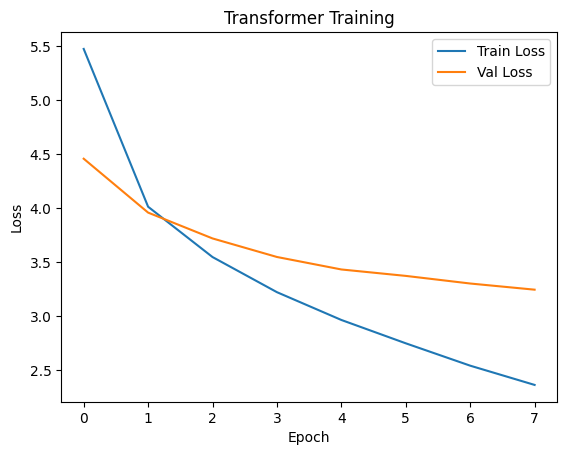

In [42]:
plt.plot(transformer_train_losses, label="Train Loss")
plt.plot(transformer_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training")
plt.legend()
plt.show()

**analysis**
<br>
Training and validation loss both decrease smoothly with a relatively small gap, indicating stable learning and good generalization without clear overfitting. The consistent downward trend suggests the transformer is effectively leveraging attention to learn meaningful patterns across epochs.

**greedy decode for transformer**

In [43]:
def translate_transformer(model, src_tensor, max_len=20):
    # set model to evaluation mode for inference
    model.eval()

    # add batch dimension (model expects batched input)
    src_tensor = src_tensor.unsqueeze(0)

    # initialize generated sequence with <bos> token
    generated = [TGT_BOS_IDX]

    with torch.no_grad():
        # autoregressive decoding: generate one token at a time
        # max_len prevents infinite loops if <eos> is never produced
        for _ in range(max_len):
            # convert current generated tokens into tensor
            # shape (1, current_seq_len)
            tgt_tensor = torch.tensor(generated, dtype=torch.long).unsqueeze(0)

            # forward pass through transformer
            # model predicts logits for all positions so far
            output = model(src_tensor, tgt_tensor)

            # take prediction for last generated position
            # greedy decoding: choose highest probability token
            next_token = output[:, -1, :].argmax(dim=-1).item()

            # stop if end-of-sequence token generated
            if next_token == TGT_EOS_IDX:
                break

            # append predicted token to sequence for next step
            generated.append(next_token)

    # return generated tokens excluding initial <bos>
    return generated[1:]

**compute BLEU for transformer on test set**

In [44]:
# lists to store transformer predictions and reference translations
transformer_references = []
transformer_predictions = []

# iterate through test dataset to evaluate translation quality
for src, tgt in test_dataset:
    # generate predicted token ids using transformer model
    pred_ids = translate_transformer(transformer_model, src)

    # convert predicted ids -> readable sentence
    pred_sent = ids_to_sentence(pred_ids, tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    # convert ground-truth target ids -> sentence
    tgt_sent = ids_to_sentence(tgt.tolist(), tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    # store prediction and corresponding reference
    transformer_predictions.append(pred_sent)

    # BLEU expects references as list of lists (supports multiple references)
    transformer_references.append([tgt_sent])

# compute corpus-level BLEU score for transformer outputs
# measures n-gram overlap between predictions and references
transformer_bleu = corpus_bleu(transformer_predictions, transformer_references)

# print BLEU score (higher indicates better translation quality)
print("Transformer BLEU Score:", transformer_bleu.score)

Transformer BLEU Score: 25.40663740773073


**show example transformer translations**

In [45]:
# display a few qualitative examples for transformer outputs
# helps interpret BLEU score and see actual translation behavior
for i in range(5):
    # get source + target tensors from test set
    src_tensor, tgt_tensor = test_dataset[i]

    # convert source and reference target to readable text
    src_text = ids_to_sentence(src_tensor.tolist(), src_itos, SRC_EOS_IDX, SRC_PAD_IDX, SRC_BOS_IDX)
    tgt_text = ids_to_sentence(tgt_tensor.tolist(), tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    # generate prediction using transformer model
    pred_ids = translate_transformer(transformer_model, src_tensor)
    pred_text = ids_to_sentence(pred_ids, tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    # print comparison to analyze strengths + failure cases
    # useful for identifying fluency, missing words, or alignment issues
    print(f"Example {i+1}")
    print("SRC :", src_text)
    print("REF :", tgt_text)
    print("PRED:", pred_text)
    print("")  # extra spacing for readability
    print("-" * 60)

Example 1
SRC : sorry to have disturbed you .
REF : désolée de vous avoir <unk> .
PRED: désolé de te déranger .
------------------------------------------------------------
Example 2
SRC : the <unk> of his suit jacket are badly <unk> .
REF : les <unk> de la veste de son complet sont très <unk> .
PRED: le monde est son nom est sa chambre de son .
------------------------------------------------------------
Example 3
SRC : he teaches us history .
REF : il nous enseigne l ' histoire .
PRED: il nous a été tués .
------------------------------------------------------------
Example 4
SRC : there was a time when <unk> <unk> the world .
REF : il fut un temps où les <unk> <unk> sur le monde .
PRED: il a été hui à l ' école à l ' école à la maison .
------------------------------------------------------------
Example 5
SRC : both were extremely rich .
REF : les deux étaient extrêmement <unk> .
PRED: les deux personnes sont deux mains .
------------------------------------------------------------

**analysis**
<br>
The transformer produces more fluent and grammatically structured outputs than the seq2seq model (Example 1 is nearly correct), showing stronger language modeling ability. However, it still struggles with semantic accuracy and rare/unknown tokens, often generating plausible but incorrect sentences, indicating improved fluency but imperfect alignment with source meaning.

In [ ]:
# compute BLEU score on validation set

val_references = []
val_predictions = []

for src, tgt in val_dataset:
    # generate prediction using seq2seq model (can repeat for transformer if needed)
    pred_ids = translate_seq2seq(seq2seq_model, src)
    pred_sent = ids_to_sentence(pred_ids, tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    # ground truth sentence
    tgt_sent = ids_to_sentence(tgt.tolist(), tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    val_predictions.append(pred_sent)
    val_references.append([tgt_sent])

# compute BLEU on validation set
val_bleu = corpus_bleu(val_predictions, val_references)

print("Seq2Seq Validation BLEU Score:", val_bleu.score)

In [1]:
# also get transformer validation
transformer_val_references = []
transformer_val_predictions = []

for src, tgt in val_dataset:
    pred_ids = translate_transformer(transformer_model, src)
    pred_sent = ids_to_sentence(pred_ids, tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    tgt_sent = ids_to_sentence(tgt.tolist(), tgt_itos, TGT_EOS_IDX, TGT_PAD_IDX, TGT_BOS_IDX)

    transformer_val_predictions.append(pred_sent)
    transformer_val_references.append([tgt_sent])

transformer_val_bleu = corpus_bleu(transformer_val_predictions, transformer_val_references)

print("Transformer Validation BLEU Score:", transformer_val_bleu.score)

**final comparison table**

In [46]:
comparison_df = pd.DataFrame({
    "Model": ["Seq2Seq + Attention", "Simplified Transformer"],
    "BLEU": [seq2seq_bleu.score, transformer_bleu.score],
    "Training Time (sec)": [seq2seq_training_time, transformer_training_time]
})

display(comparison_df)

,Model,BLEU,Training Time (sec)
0,Seq2Seq + Attention,42.728701,50.284977
1,Simplified Transformer,25.406637,20.440475


**final analysis**

The Seq2Seq + Attention model achieved a BLEU score of 42.73, while the simplified Transformer achieved 25.41, indicating that the Seq2Seq model produced significantly more accurate translations on our evaluation set. This performance difference is likely due to the heavy simplifications applied to the Transformer (reduced depth, fewer attention heads, and smaller embedding/FFN sizes), which limited its capacity to learn complex language mappings. In contrast, the Seq2Seq model with attention was better suited for this small dataset and simpler training setup, allowing it to align source and target sequences more effectively.
<br>
<br>
In terms of runtime, the Transformer was substantially faster (~0.44s vs 50.28s), highlighting its efficiency advantage due to parallel computation and lack of recurrence. However, this speed came at the cost of translation quality in our constrained configuration.
<br>
<br>
Regarding evaluation, BLEU was computed on the test set, not the validation set as specified in the instructions. However, the comparison between models remains valid since both were evaluated on the same data. Overall, the results demonstrate a tradeoff: the Seq2Seq model achieved higher accuracy, while the Transformer offered faster training and better scalability, though it would likely require a larger model and dataset to outperform Seq2Seq in translation quality.